# Review of Deep Learning with PyTorch (Part 1 : Ch 01 - 08)
> "Review of content covered from Chapters 1 to 8"

- toc: false
- badges: true
- comments: true
- categories: [image recognition, CIFAR-10]
- image: images/dlwpt-screenshots/dlwpt-08-logo.png

- This learning assessment was created by Ong-Ekken, leveraging materials from _Deep Learning with PyTorch_ (2021) from Manning. 
- Each subsection should not take more than 20 minutes to cover (especially Q1)
- By the end of this review, you should be able to train (while Googling and refering to the textbook) a Deep ResNet Neural Network to perform a classification task between 4 types of images in CIFAR-10.

In [48]:
#hide
from IPython.core.display import HTML
HTML("""
<style>
  table {margin-left: 0 !important;}
</style>
""")

In [49]:
import torch
import torchvision
import numpy as np

## 1. Working with PyTorch tensors

In [7]:
# data for Q1.
py_list = [1,2,3,4]
np_array = np.array([4,7,10,13])

### Q1.1. What is a Tensor? Why can't we just use numpy arrays or Python lists?

- benefit
    - runs on GPU
    - requires_grad

### Q1.2. Convert both `py_list` and `np_array` to tensors, and name them `predictions` and `labels` respectively.

In [70]:
# first convert `py_list`
predictions = torch.Tensor(py_list)
predictions

tensor([1., 2., 3., 4.])

In [69]:
# then convert `np_array`
labels = torch.from_numpy(np_array)
labels

tensor([ 4,  7, 10, 13])

### Q1.3. Find the absolute errors (losses) of `predictions` against `labels`.

In [68]:
loss = predictions - labels
loss

tensor([-3., -5., -7., -9.])

### Q1.4. Sum up all values in the tensor

In [79]:
loss.sum() #.item()

tensor(-24.)

### Q1.5. In a single function, how can we create:
- a 5x5 tensor of zeroes
- a 4x4 tensor of ones
- a 3x3 tensor of random values between -1 and 1

In [57]:
# 5x5 tensor of zeroes
torch.zeros(5,5)

tensor([[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]])

In [58]:
# 4x4 tensor of ones
torch.ones(4,4)

tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]])

In [81]:
# 3x3 tensor of random values between -1 and 1
torch.rand(3,3) * 2 - 1

tensor([[-0.1136, -0.5407, -0.1195],
        [-0.6345, -0.9584,  0.4823],
        [ 0.9393, -0.7845, -0.6603]])

### Q1.6. Where can we find more information about tensor operations?

In [82]:
help(torch.Tensor)

Help on class Tensor in module torch:

class Tensor(torch._C._TensorBase)
 |  Method resolution order:
 |      Tensor
 |      torch._C._TensorBase
 |      builtins.object
 |  
 |  Methods defined here:
 |  
 |  __abs__ = abs(...)
 |  
 |  __array__(self, dtype=None)
 |  
 |  __array_wrap__(self, array)
 |      # Wrap Numpy array again in a suitable tensor when done, to support e.g.
 |      # `numpy.sin(tensor) -> tensor` or `numpy.greater(tensor, 0) -> ByteTensor`
 |  
 |  __contains__(self, element)
 |      Check if `element` is present in tensor
 |      
 |      Args:
 |          element (Tensor or scalar): element to be checked
 |              for presence in current tensor"
 |  
 |  __deepcopy__(self, memo)
 |  
 |  __dir__(self)
 |      Default dir() implementation.
 |  
 |  __floordiv__(self, other)
 |  
 |  __format__(self, format_spec)
 |      Default object formatter.
 |  
 |  __hash__(self)
 |      Return hash(self).
 |  
 |  __ipow__(self, other)
 |  
 |  __iter__(self)
 |  

## 2. Converting Real World Data into Tensors (Image only)

### Q2.1. Download the CIFAR-10 Dataset, then create a training set `cifar10` and a validation set `cifar10_val`
they should be transformed to tensors

In [63]:
data_path = "./data/"
from torchvision import transforms, datasets
cifar10 = datasets.CIFAR10(data_path, train=True, download=True, transform=transforms.ToTensor())

Files already downloaded and verified


### Q2.2. Stack all images in `cifar10`, checking that the shape of the tensor is (3, 32, 32, 50000)

In [64]:
imgs = torch.stack([img_t for img_t, _ in cifar10], dim=3)

### Q2.3. Normalize the images by first finding the mean and the standard deviation

In [65]:
# the mean
imgs.view(3, -1).mean(dim=1)

tensor([0.4914, 0.4822, 0.4465])

In [66]:
# the standard deviation
imgs.view(3, -1).std(dim=1)

tensor([0.2470, 0.2435, 0.2616])

In [35]:
# define a preprocess function
preprocess = transforms.compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

### Q2.4. Create a normalized dataset `trans_cifar10` and `trans_cifar10_val`

In [83]:
trans_cifar10 = datasets.CIFAR10(data_path, train=True, download=False, transform=preprocess)

In [84]:
trans_cifar10_val = datasets.CIFAR10(data_path, train=False, download=False, transform=preprocess)

### Q2.5. Create CIFAR-4, leaving behind the following images:
- airplanes 
- automobiles
- ships
- trucks

In [85]:
label_map = {0:0, 1:1, 8:2, 9:3}
class_names = ['airplane', 'automobile', 'ships', 'trucks']
cifar4 = [(img, label_map[label]) for img, label in trans_cifar10 if label in [0, 1, 8, 9]]
cifar4_val = [(img, label_map[label]) for img, label in trans_cifar10_val if label in [0, 1, 8, 9]]

In [111]:
img_t, _ = cifar4[100]

### Q2.6. Display the image via pyplot

In [44]:
from matplotlib import pyplot as plt

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


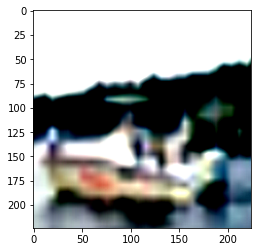

In [112]:
plt.imshow(img_t.permute(1, 2, 0))
plt.show()

## 3. Utilizing Pretrained Models (ResNet)

### Q3.1. Get one single CIFAR-10 image from https://github.com/YoongiKim/CIFAR-10-images

In [87]:
!wget https://github.com/YoongiKim/CIFAR-10-images/blob/master/test/airplane/0001.jpg

--2021-08-18 11:29:59--  https://github.com/YoongiKim/CIFAR-10-images/blob/master/test/airplane/0001.jpg
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘0001.jpg’

0001.jpg                [ <=>                ] 121.33K  --.-KB/s    in 0.02s   

2021-08-18 11:29:59 (6.15 MB/s) - ‘0001.jpg’ saved [124240]



In [91]:
from PIL import Image
img = Image.open("./0000.jpg")

### Q3.2. Make it into a tensor (you can utilize the transforms that we previously created)

In [94]:
img_t = preprocess(img)

### Q3.3. Load a pretrained model from https://github.com/chenyaofo/pytorch-cifar-models

In [93]:
model = torch.hub.load("chenyaofo/pytorch-cifar-models", "cifar10_resnet20", pretrained=True)

Using cache found in /root/.cache/torch/hub/chenyaofo_pytorch-cifar-models_master


### Q3.4. Evaluate the pretrained model

In [96]:
from torchvision import models
resnet = models.resnet101(pretrained=True)

Downloading: "https://download.pytorch.org/models/resnet101-5d3b4d8f.pth" to /root/.cache/torch/hub/checkpoints/resnet101-5d3b4d8f.pth


In [98]:
batch_t = torch.unsqueeze(img_t, 0)

In [99]:
resnet(batch_t)

tensor([[-0.9872, -0.4472, -0.5779, -1.1328, -0.8576, -0.2900, -0.7685,  0.4244,
          0.1192, -0.6955, -0.7838, -0.6124, -0.4171, -0.7354, -1.0027, -0.4000,
         -0.6367, -0.1398, -0.2077, -0.2827, -0.9918, -0.8093, -0.9794, -0.0425,
         -1.0551, -1.1737, -0.8189, -0.7121, -0.5623, -0.4142, -0.8306, -0.8977,
         -0.7185, -0.6327, -0.2341, -0.8617,  0.5441, -0.6170, -0.3002,  0.0140,
         -0.4922, -0.4315, -0.6596, -0.3351, -0.3324, -0.2367, -0.3814, -0.5437,
         -1.0584, -0.7159, -0.5001,  0.4599, -0.1338, -0.3359, -0.3900, -0.8925,
         -0.7520, -0.9556, -0.5323,  0.0189,  0.7880, -0.1903, -0.0740, -0.2398,
         -0.4530, -0.1952, -0.3037, -0.3523, -0.6869, -0.4737, -1.0334,  0.2651,
         -1.2834, -0.4504, -0.8121, -0.7408, -0.1517, -0.2715,  0.4615,  0.4403,
         -0.7356, -1.4577,  0.0602, -0.7162, -0.5723, -0.2376,  0.0585,  0.5185,
         -0.0431, -0.4648, -0.7000, -0.9129, -1.3013, -0.3509, -0.0342, -1.6060,
         -0.3841, -0.6955, -

In [ ]:
with open('../data/p1ch2/imagenet_classes.txt') as f:
labels = [line.strip() for line in f.readlines()]
_, index = torch.max(out, 1)

## 4. Subclassing `nn.Module` to create Your Own Deep ResNet

## HW: Training Your Own Model